# 实验七：图像边缘检测与阈值分割

**实验目的：**
学习提取图像边缘的多种微分算子，掌握自动阈值选择方法（大津法）以实现目标分割。

**实验准备：**
准备一张有明显主体和边缘的灰度图像，重命名为 `lena.jpg` 或 `test.jpg` 放在当前目录下。


图像读取成功！尺寸: (240, 320)


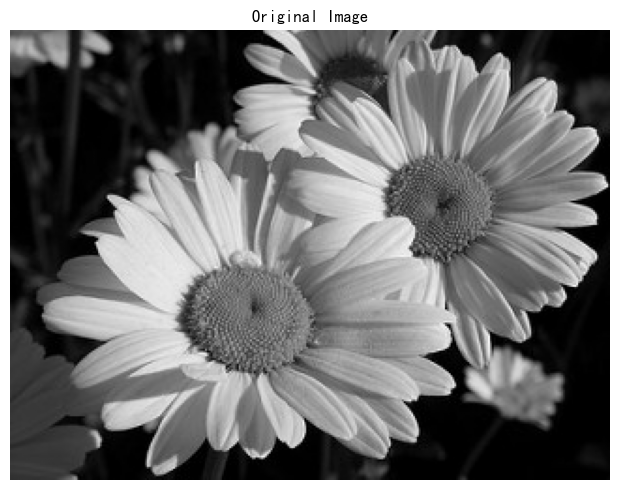

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

def show_images(images, titles, figsize=(15, 5)):
    n = len(images)
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap='gray', vmin=0, vmax=255)
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# 读取原始图像并转为灰度图
img = cv2.imread('lena.jpg', cv2.IMREAD_GRAYSCALE)
if img is None:
    print("⚠️ 找不到 lena.jpg，请准备一张图片！为了展示分割效果，建议找一张背景和前景有一定区分度的图。")
else:
    print(f"图像读取成功！尺寸: {img.shape}")
    show_images([img], ["Original Image"])


## 1. 经典微分算子 (Sobel & Prewitt)
边缘在数学上的表现就是**“灰度值发生剧烈变化的地方”**，因此对图像求一阶导数（梯度）就能找到边缘。
* **Sobel 算子**：带平滑功能的梯度算子，抗噪能力好，是最常用的基础算子。
* **Prewitt 算子**：与 Sobel 类似，但中心权重没有加强，对噪声稍微敏感一些。


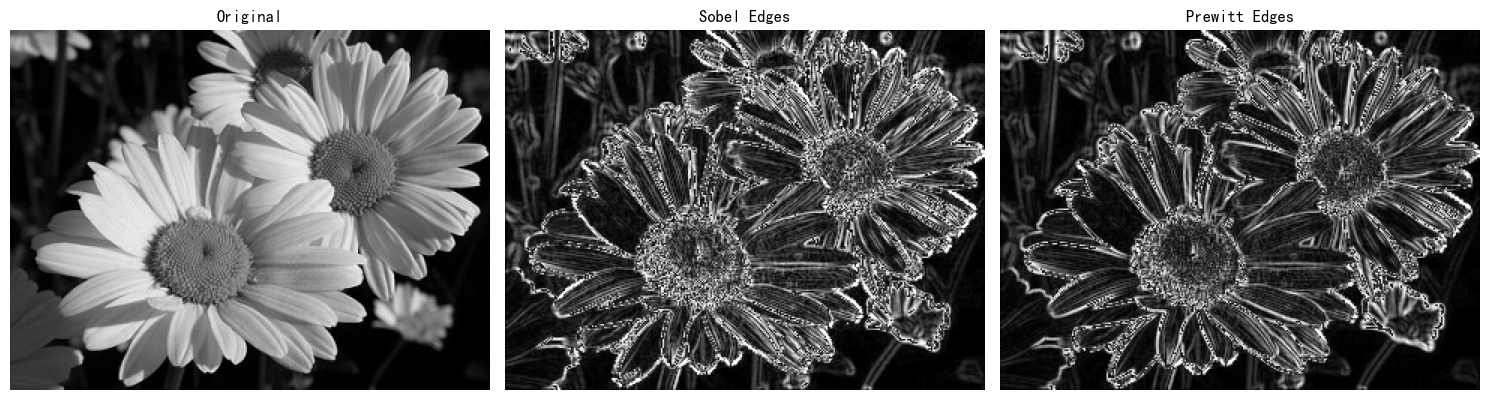

In [2]:
if img is not None:
    # --- 1. Sobel 算子 ---
    # 计算 x 方向梯度 (检测垂直边缘) 和 y 方向梯度 (检测水平边缘)
    # 注意：求导会出现负数，必须用 64 位浮点数 CV_64F 接收
    sobel_x = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    # 转回 uint8 并将 x 和 y 方向的边缘叠加
    sobel_combined = cv2.convertScaleAbs(sobel_x) + cv2.convertScaleAbs(sobel_y)

    # --- 2. Prewitt 算子 ---
    # OpenCV 没有直接的 Prewitt 函数，我们需要手动定义卷积核
    kernel_prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    kernel_prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

    prewitt_x = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_x)
    prewitt_y = cv2.filter2D(img, cv2.CV_64F, kernel_prewitt_y)
    prewitt_combined = cv2.convertScaleAbs(prewitt_x) + cv2.convertScaleAbs(prewitt_y)

    show_images([img, sobel_combined, prewitt_combined], 
                ["Original", "Sobel Edges", "Prewitt Edges"])


## 2. 工业界标杆：Canny 边缘检测算法

Canny 并不是一个简单的卷积核，而是一个包含四步的多级算法：
1. 高斯模糊去噪。
2. 计算梯度幅值和方向。
3. **非极大值抑制**（把粗糙的边缘变细，只保留真正的边界点）。
4. **双阈值滞后过滤**（通过高低阈值连接断开的边缘）。


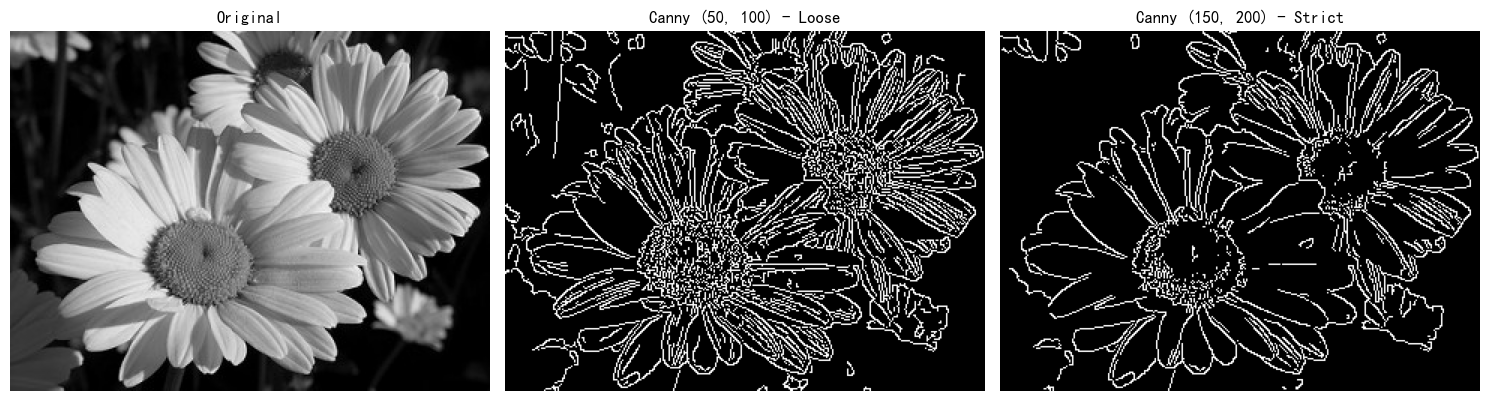

💡 结论：观察 Canny 提取的线条，它比 Sobel 提取的单像素线条更细、更连续！


In [3]:
if img is not None:
    # 尝试不同的高低阈值组合
    # 宽容模式：下限低，容易保留细碎的纹理和噪点
    canny_loose = cv2.Canny(img, threshold1=50, threshold2=100)

    # 严格模式：下限高，只保留对比非常强烈的强边缘
    canny_strict = cv2.Canny(img, threshold1=150, threshold2=200)

    show_images([img, canny_loose, canny_strict], 
                ["Original", "Canny (50, 100) - Loose", "Canny (150, 200) - Strict"])
    print("💡 结论：观察 Canny 提取的线条，它比 Sobel 提取的单像素线条更细、更连续！")


## 3. 图像分割：手动阈值 vs 大津法 (Otsu's Method)

图像分割的目的是把目标从背景中抠出来。最简单的方法是找一个灰度值作为“门槛”（阈值）。
* **全局阈值**：人为主观设定一个固定值（例如 127），大于它的变白，小于它的变黑。
* **大津法 (Otsu)**：它会遍历所有可能的阈值，通过计算前景和背景的**类间方差**，自动找到能完美将两者切开的最佳阈值。


👉 大津法自动计算出的最佳阈值为: 90.0


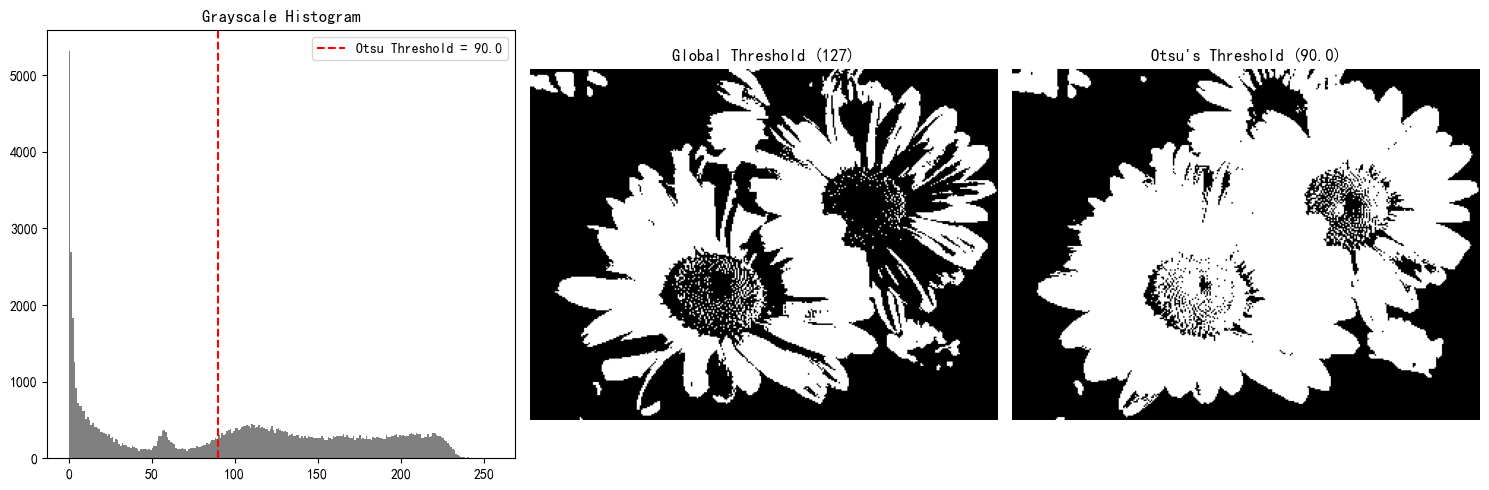

In [4]:
if img is not None:
    # 1. 手动设定全局阈值为 127
    ret_global, th_global = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # 2. 大津法自动寻找阈值
    # 注意：需要多加一个 cv2.THRESH_OTSU 标志，且设定的阈值 0 不起作用，函数会返回自动计算出的最佳阈值
    ret_otsu, th_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    print(f"👉 大津法自动计算出的最佳阈值为: {ret_otsu}")

    # 可视化：绘制直方图，并在上面画出大津法找到的阈值线
    plt.figure(figsize=(15, 5))

    # 画直方图
    plt.subplot(1, 3, 1)
    plt.hist(img.ravel(), bins=256, range=(0, 256), color='gray')
    plt.axvline(x=ret_otsu, color='red', linestyle='--', label=f'Otsu Threshold = {ret_otsu}')
    plt.title('Grayscale Histogram')
    plt.legend()

    # 显示全局手动阈值结果
    plt.subplot(1, 3, 2)
    plt.imshow(th_global, cmap='gray')
    plt.title(f'Global Threshold (127)')
    plt.axis('off')

    # 显示大津法结果
    plt.subplot(1, 3, 3)
    plt.imshow(th_otsu, cmap='gray')
    plt.title(f"Otsu's Threshold ({ret_otsu})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()
